# Retrieval Augmented Generation (RAG)
> Enhancing AI with Knowledge

RAG (Retrieval Augmented Generation) is a powerful AI architecture that combines information retrieval with text generation to produce more accurate and contextually relevant responses. It represents a significant advancement in how AI systems access and utilize knowledge.

## What is RAG?

RAG works by:
1. **Retrieving** relevant information from a knowledge base
2. **Augmenting** the input prompt with this retrieved context 
3. **Generating** responses using both the original prompt and retrieved information

## Why is RAG Important?

RAG addresses a fundamental limitation of Large Language Models (LLMs): they can't directly answer questions about specific or up-to-date information that wasn't part of their training data. Some use cases require:

- Access to private or proprietary information
- Real-time or frequently updated data
- Domain-specific knowledge
- Company-specific policies and procedures

By incorporating a retrieval system, RAG enables LLMs to access and leverage this additional context when generating responses, making them more accurate and useful for specialized applications.

## How RAG Works
The example of use case of RAG is to query a database using natural language. We can give a prompt to the LLM to query the database and the LLM will generate the SQL query to get the data.

### RAG System Flowchart
> This is the flowchart of RAG system for natural language database querying:

In [22]:
#|echo: false

import base64
from IPython.display import Image, display
import matplotlib.pyplot as plt

def mm(graph):
    graphbytes = graph.encode("utf8")
    base64_bytes = base64.urlsafe_b64encode(graphbytes)
    base64_string = base64_bytes.decode("ascii")
    display(Image(url="https://mermaid.ink/img/" + base64_string))

mm("""
flowchart TD
    A[User Query] --> B[Query Understanding]
    B --> C[Query Embedding]
    
    subgraph Retrieval
        D[Vector Database] --> E[Semantic Search]
        F[(Document Store/Database)] --> G[Document Chunks]
        G --> H[Document Embeddings]
        H --> D
    end
    
    C --> E
    E --> I[Relevant Documents/Context]
    
    subgraph Augmentation
        I --> J[Context Processing]
        J --> K[Query Reformulation]
        K --> L[SQL Generation]
    end
    
    L --> M[(Target Database)]
    M --> N[Database Results]
    
    subgraph Generation
        N --> O[Answer Generation]
        I --> O
        A --> O
    end
    
    O --> P[Final Response]
""")

### How RAG works in detail:

1. **Input Processing:**
- User submits a natural language query
- Query is analyzed for intent and key entities
- Query is converted to vector embeddings for semantic matching

2. **Retrieval Phase:**
- Documents/Database schema are pre-processed into chunks
- Chunks are converted to embeddings and stored in vector database
- System performs semantic search to find relevant context
- Retrieves most similar documents/schema information

3. **Augmentation Phase:**
- Retrieved context is processed and filtered
- Original query is reformulated with context
- SQL query is generated using the enhanced understanding

4. **Database Interaction:**
- Generated SQL queries the target database
- Results are fetched from the database

5. **Generation Phase:**
- Combines original query, context, and database results
- Generates natural language response
- Returns formatted answer to user

## Example to Build RAG System

### System Flowchart

In [23]:
#|echo: false

mm("""
   flowchart TD
    A[User Natural Language Query] --> B[Query Embedding]
    C[BigQuery Schema] --> D[Schema Embedding]
    
    subgraph Model Processing
        B --> E[LLM]
        D --> E
        E --> F[SQL Query Generation]
        E --> G[Data Analysis]
        E --> H[Visualization Code]
    end
    
    F --> I[(BigQuery Database)]
    I --> J[Query Results]
    
    J --> K[Data Analysis Results]
    K --> L[Matplotlib Visualization]
    
    subgraph Final Output
        K --> M[Analysis Response]
        L --> M
    end
   """)

The flowchart above illustrates the end-to-end process of our RAG (Retrieval-Augmented Generation) system:

1. The process begins with a user's natural language query, which is converted into an embedding
2. In parallel, the BigQuery schema is also embedded
3. The Model Processing phase includes:
   - An LLM that processes both embeddings
   - Generation of SQL queries
   - Data analysis logic
   - Visualization code generation
4. The generated SQL query is executed against BigQuery database to fetch results
5. The query results flow into:
   - Data analysis processing
   - Matplotlib visualization generation
6. Finally, both the analysis results and visualizations are combined into a comprehensive response for the user
This architecture enables natural language interactions with data while providing both analytical insights and visual representations.


### Code Example

I0000 00:00:1735895683.666072 26569273 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported



🔍 Question: Show me the daily sales trend for the past week?


📝 Generated SQL Query:
   SELECT 
  DATE(transaction_datetime) AS transaction_date,
  SUM(revenue) AS total_revenue
FROM 
  `sukses-group-398313.playground.captain_transaction_details`
WHERE 
  DATE(transaction_datetime) BETWEEN DATE_SUB(CURRENT_DATE(), INTERVAL 7 DAY) AND CURRENT_DATE()
GROUP BY 
  transaction_date
ORDER BY 
  transaction_date ASC


I0000 00:00:1735895691.762848 26569273 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported



📊 Query Results Preview:
  transaction_date  total_revenue
0       2024-12-27      797630000
1       2024-12-28      868785000
2       2024-12-29      959685000
3       2024-12-30      843480000
4       2024-12-31      726495000


📈 Analysis:
Visualization Explanation:

In this example, the visualization would be a line graph showing daily sales over the past week. On the x-axis, we have the transaction date, and on the y-axis, we have the total revenue for each day. Each point on the graph represents the total revenue for a specific day, and these points are connected by a line to show the trend over time.

Key Insights:

1. The sales revenue is not constant and varies from day to day. 
2. There is a significant increase in total revenue from 27th to 29th of December, peaking at 959,685,000.
3. The revenue then drops on 30th and 31st of December, with the lowest point of the week at 726,495,000 on the 31st.
4. However, the revenue bounces back up on 2nd January, reaching 950,505,000,

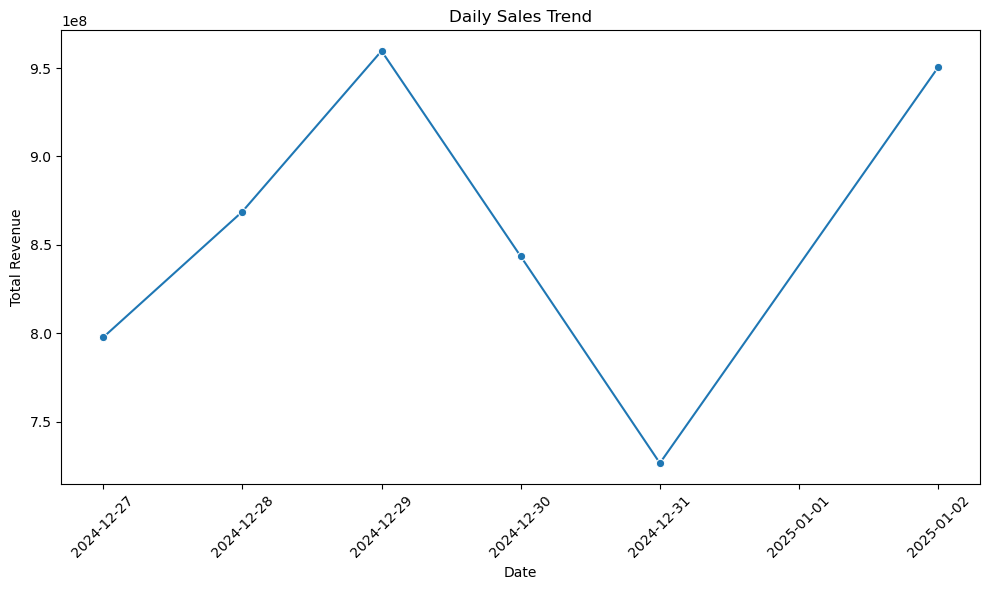

In [26]:
#|code-fold: show

import matplotlib.pyplot as plt
import seaborn as sns
from typing import Union, Tuple
import warnings
import logging

# Filter out specific warnings and logs
warnings.filterwarnings('ignore', category=FutureWarning)
logging.getLogger('google.cloud.bigquery').setLevel(logging.ERROR)
logging.getLogger('google.api_core').setLevel(logging.ERROR)

# BigQuery table variables
project_id = "sukses-group-398313" #|hide_line
dataset_id = "playground" #|hide_line
table_id = "captain_transaction_details" #|hide_line
# project_id = ""
# dataset_id = ""
# table_id = ""

class RAGQueryEngine:
    def __init__(self):
        """Initialize with table schema"""
        schema_query = f"""
        SELECT 
            column_name, data_type
        FROM `{project_id}.{dataset_id}.INFORMATION_SCHEMA.COLUMNS` 
        WHERE table_name = '{table_id}'
        """
        schema_df = bq_client.query(schema_query).to_dataframe()
        self.schema = schema_df.to_dict('records')
        
    def get_sql_query(self, user_question: str) -> str:
        """Generate SQL query from natural language question"""
        schema_str = "\n".join([f"- {col['column_name']}: {col['data_type']}" for col in self.schema])
        
        prompt = f"""
        Convert this question to a SQL query for BigQuery:
        {user_question}
        
        Use the table: `{project_id}.{dataset_id}.{table_id}`
        
        Table schema:
        {schema_str}
        
        The query should:
        - Be valid SQL that starts with SELECT
        - Return relevant data for visualization using the correct columns from the schema
        - Include date/time fields if asking about trends
        - Use proper table names and column references
        - Not include any explanatory text, only the SQL query
        """
        
        response = client.chat.completions.create(
            model="gpt-4",
            messages=[
                {"role": "system", "content": "You are an expert SQL writer. Write only valid BigQuery SQL queries without any explanatory text. Always use fully qualified table names."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.3
        )
        
        sql = response.choices[0].message.content.strip()
        # Ensure query starts with SELECT
        if not sql.upper().startswith('SELECT'):
            raise ValueError("Invalid SQL query generated")
        return sql

    def generate_visualization(self, df, question: str) -> Tuple[str, plt.Figure]:
        """Generate visualization and explanation based on data"""
        # Create figure
        plt.close('all')  # Close all existing figures
        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_subplot(111)
        
        # For time series data with dates and numeric values, default to line plot
        if 'transaction_date' in df.columns and 'total_revenue' in df.columns:
            sns.lineplot(data=df, x='transaction_date', y='total_revenue', ax=ax, marker='o')
            plt.title('Daily Sales Trend')
            plt.xlabel('Date')
            plt.ylabel('Total Revenue')
            plt.xticks(rotation=45)
            plt.tight_layout()
            return self.generate_explanation(df, question), fig
            
        # If not a time series, use the AI recommendation approach
        prompt = f"""
        Question: {question}
        
        Data columns: {', '.join(df.columns)}
        Sample data: {df.head().to_string()}
        
        What type of plot would best visualize this data? Choose from:
        1. Line plot (for trends over time)
        2. Bar plot (for comparisons)
        3. Scatter plot (for relationships)
        4. Pie chart (for composition)
        
        Provide your recommendation in format:
        PLOT_TYPE: <type>
        X_AXIS: <column>
        Y_AXIS: <column>
        TITLE: <title>
        """
        
        response = client.chat.completions.create(
            model="gpt-4",
            messages=[
                {"role": "system", "content": "You are a data visualization expert. Recommend the best chart type."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.3
        )
        
        viz_specs = response.choices[0].message.content.strip().split('\n')
        plot_type = viz_specs[0].split(': ')[1].lower()
        x_col = viz_specs[1].split(': ')[1]
        y_col = viz_specs[2].split(': ')[1]
        title = viz_specs[3].split(': ')[1]

        # Create visualization based on type
        try:
            if plot_type == 'line':
                df = df.sort_values(by=x_col)
                sns.lineplot(data=df, x=x_col, y=y_col, ax=ax, marker='o')
            elif plot_type == 'bar':
                sns.barplot(data=df, x=x_col, y=y_col, ax=ax)
            elif plot_type == 'scatter':
                sns.scatterplot(data=df, x=x_col, y=y_col, ax=ax)
            elif plot_type == 'pie':
                plt.pie(df[y_col], labels=df[x_col], autopct='%1.1f%%')
            
            plt.title(title)
            if plot_type != 'pie':
                plt.xticks(rotation=45)
            plt.tight_layout()
            
        except Exception as e:
            print("\n❌ Error generating visualization:")
            print(f"   {str(e)}")
            
        return self.generate_explanation(df, question), fig

    def generate_explanation(self, df, question: str) -> str:
        """Generate explanation of the visualization"""
        explanation_prompt = f"""
        Question: {question}
        
        Data Results:
        {df.to_string()}
        
        Please provide a clear, concise explanation of the visualization and key insights.
        """
        
        explanation = client.chat.completions.create(
            model="gpt-4",
            messages=[
                {"role": "system", "content": "You are a helpful data analyst. Explain visualizations clearly."},
                {"role": "user", "content": explanation_prompt}
            ],
            temperature=0.7
        )
        
        return explanation.choices[0].message.content.strip()

    def query(self, question: str) -> Tuple[str, plt.Figure]:
        """Main method to process natural language query"""
        try:
            # Generate SQL
            sql_query = self.get_sql_query(question)
            print("\n📝 Generated SQL Query:")
            print(f"   {sql_query}")
            
            # Execute query
            query_job = bq_client.query(sql_query)
            results = query_job.result().to_dataframe()
            print("\n📊 Query Results Preview:")
            print(f"{results.head().to_string()}\n")
            
            # Generate visualization and explanation
            explanation, fig = self.generate_visualization(results, question)
            
            return explanation, fig
            
        except Exception as e:
            print("\n❌ Error occurred:")
            print(f"   {str(e)}")
            return f"Error processing query: {str(e)}", None

def main(question: str):
    rag_engine = RAGQueryEngine()
    print("\n" + "="*50)
    print(f"🔍 Question: {question}")
    print("="*50 + "\n")
    
    explanation, fig = rag_engine.query(question)
    
    print("\n" + "="*50)
    print("📈 Analysis:")
    print(f"{explanation}")
    print("="*50)
    
    if fig:
        plt.show()

if __name__ == "__main__":
    main("Show me the daily sales trend for the past week?")


## Closing
This example demonstrates the power of RAG (Retrieval Augmented Generation) in creating intelligent data analysis systems. By combining natural language processing, SQL generation, and automated visualization, RAG enables non-technical users to gain valuable insights from complex datasets through simple conversational queries.

In [25]:
#| hide
import nbdev; nbdev.nbdev_export()